# Model Comparison - Unified Analysis

**Obiettivo:** Confronto diretto di tutti i modelli addestrati senza distinzioni di tipo

**Dataset:** processed_v4_hybrid

**Modelli:**
1. XGBoost_v2
2. Random Forest
3. Decision Tree
4. MLP Baseline

**Analisi:**
- Confronto metriche
- Confusion matrices
- Feature importance
- Correlation tra predizioni
- Agreement analysis

## 1. Setup

In [6]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from collections import Counter
import pickle
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# Device setup
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"🎮 Device: {device} ({torch.cuda.get_device_name(0)})")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print(f"🍎 Device: {device} (MPS)")
else:
    device = torch.device('cpu')
    print(f"💻 Device: {device}")

print("✅ Setup completato!")

🍎 Device: mps (MPS)
✅ Setup completato!


## 2. Caricamento Metriche

In [7]:
models_dir = Path('../models')

model_paths = {
    'XGBoost': 'xgboost_v2',
    'Random Forest': 'random_forest_v2',
    'Decision Tree': 'decision_tree',
    'MLP': 'mlp_baseline'
}

metrics = {}
print("Caricamento metriche...\n")
for model_name, model_path in model_paths.items():
    metrics_file = models_dir / model_path / 'metrics.json'
    if metrics_file.exists():
        with open(metrics_file, 'r') as f:
            metrics[model_name] = json.load(f)
        print(f"✅ {model_name}")
    else:
        print(f"⚠️  {model_name} - Non trovato")

print(f"\n{len(metrics)} modelli caricati")

Caricamento metriche...

✅ XGBoost
✅ Random Forest
✅ Decision Tree
✅ MLP

4 modelli caricati


## 3. Confronto Metriche

In [8]:
def get_metric(model_metrics, metric_name):
    """Estrae metrica da structure diverse"""
    mappings = {
        'accuracy': ['test_accuracy', 'accuracy'],
        'f1': ['test_macro_f1', 'test_f1_score', 'f1_score'],
        'precision': ['test_precision', 'precision'],
        'recall': ['test_recall', 'recall'],
        'roc_auc': ['roc_auc_micro', 'test_roc_auc', 'roc_auc']
    }
    
    test_metrics = model_metrics.get('test_metrics', {})
    for key in mappings.get(metric_name, [metric_name]):
        if key in model_metrics:
            return model_metrics[key]
        if key in test_metrics:
            return test_metrics[key]
    return None

# Crea comparison dataframe
comparison_data = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [],
    'ROC AUC': []
}

for model_name, model_metrics in metrics.items():
    comparison_data['Model'].append(model_name)
    comparison_data['Accuracy'].append(get_metric(model_metrics, 'accuracy'))
    comparison_data['Precision'].append(get_metric(model_metrics, 'precision'))
    comparison_data['Recall'].append(get_metric(model_metrics, 'recall'))
    comparison_data['F1-Score'].append(get_metric(model_metrics, 'f1'))
    comparison_data['ROC AUC'].append(get_metric(model_metrics, 'roc_auc'))

comparison_df = pd.DataFrame(comparison_data)

print("=" * 100)
print("CONFRONTO METRICHE")
print("=" * 100)
print(comparison_df.to_string(index=False))
print("=" * 100)

print("\n🏆 MIGLIORI PER METRICA:")
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']:
    valid = comparison_df[comparison_df[metric].notna()]
    if len(valid) > 0:
        best_idx = valid[metric].idxmax()
        print(f"  {metric:12s}: {comparison_df.loc[best_idx, 'Model']:20s} ({comparison_df.loc[best_idx, metric]:.4f})")

CONFRONTO METRICHE
        Model  Accuracy  Precision   Recall  F1-Score  ROC AUC
      XGBoost  0.786658   0.499453 0.747525  0.598813 0.874494
Random Forest  0.774049   0.480690 0.757182  0.588057 0.870225
Decision Tree  0.783079   0.493694 0.721970  0.586400 0.860826
          MLP  0.769149   0.473517 0.749582  0.580394 0.857610

🏆 MIGLIORI PER METRICA:
  Accuracy    : XGBoost              (0.7867)
  Precision   : XGBoost              (0.4995)
  Recall      : Random Forest        (0.7572)
  F1-Score    : XGBoost              (0.5988)
  ROC AUC     : XGBoost              (0.8745)


## 4. Visualizzazione Metriche

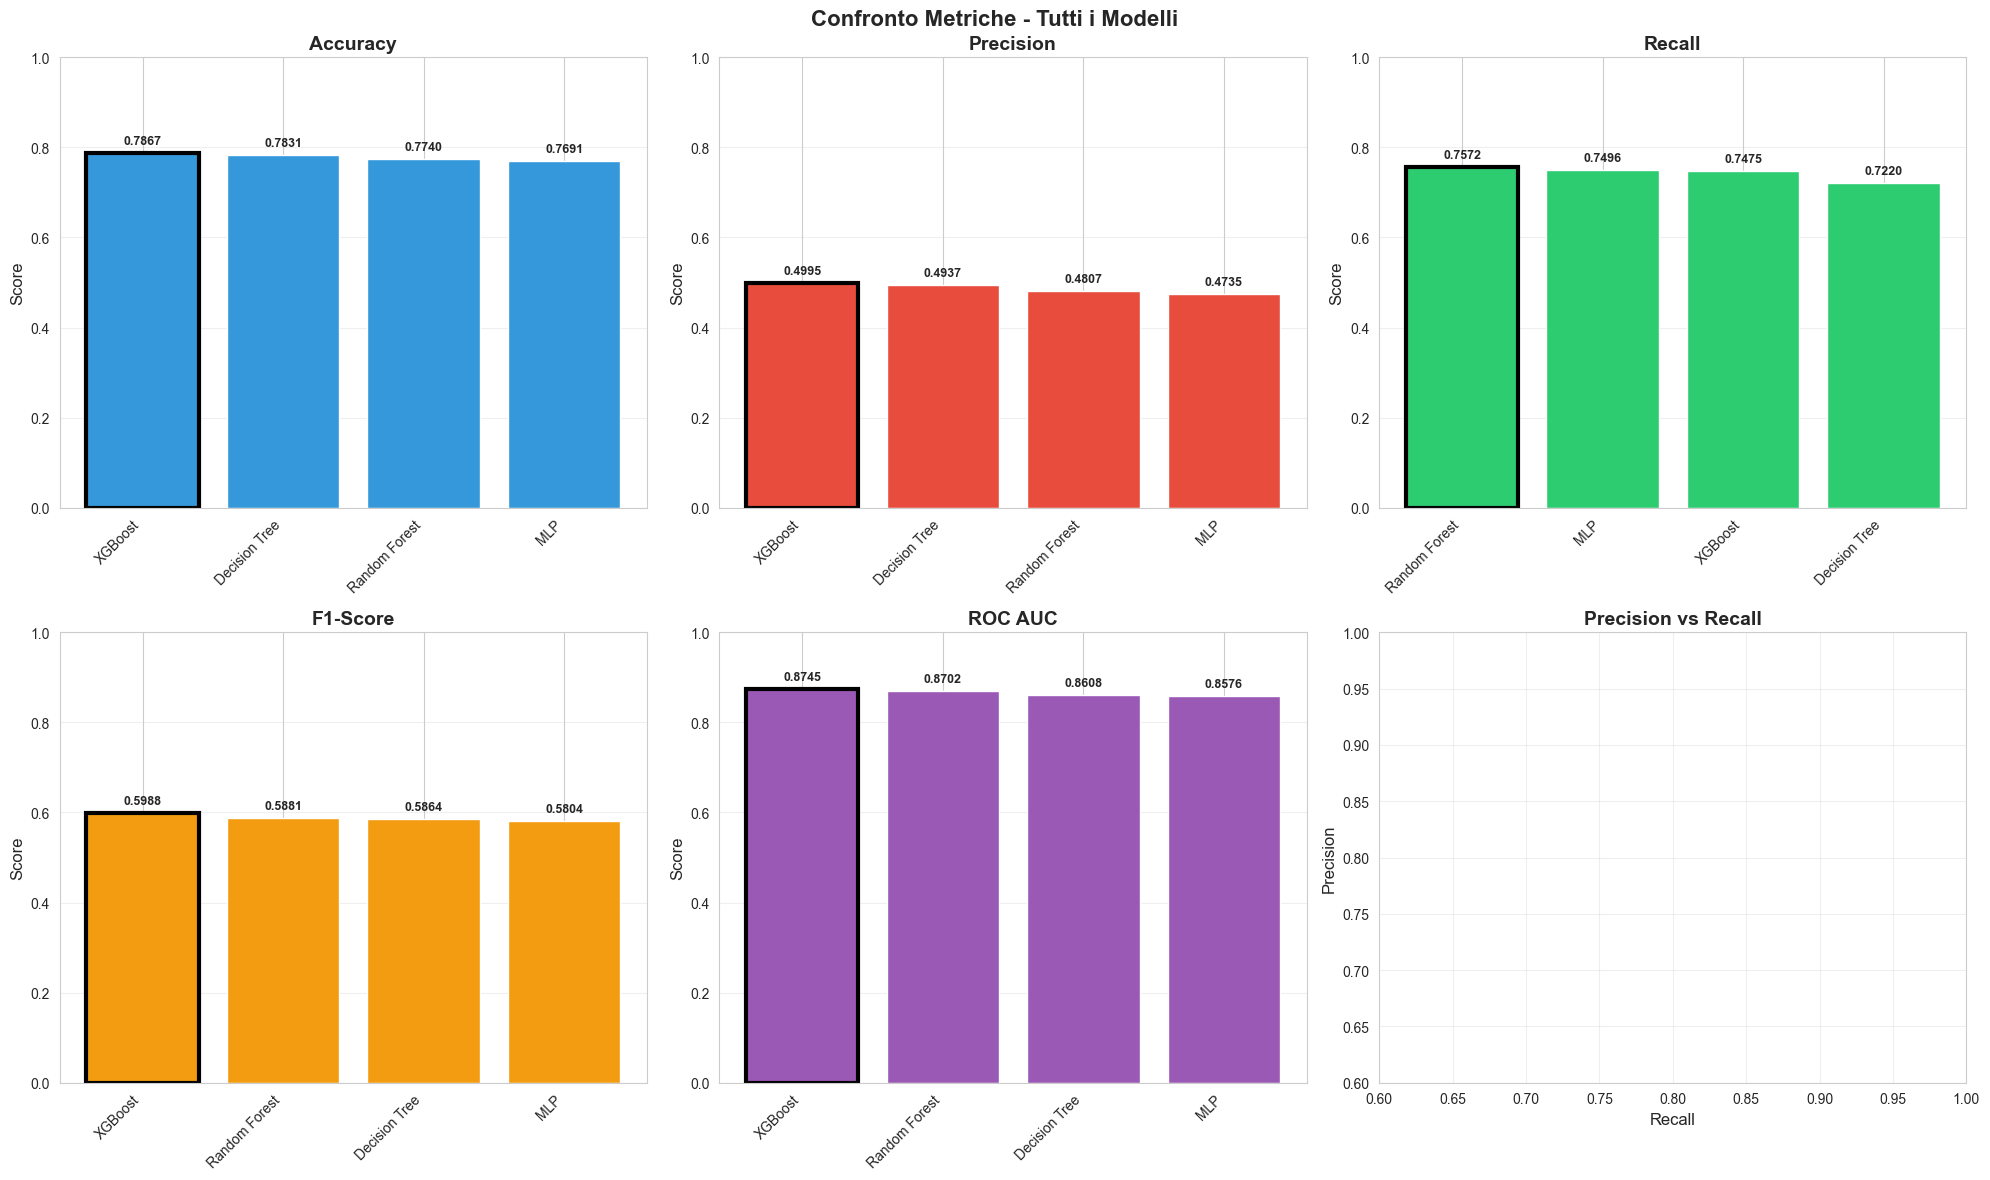

✅ Salvato: ../models/unified_metrics_comparison.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    valid = comparison_df[comparison_df[metric].notna()].copy().sort_values(metric, ascending=False)
    
    if len(valid) > 0:
        bars = ax.bar(range(len(valid)), valid[metric], color=colors[i])
        bars[0].set_edgecolor('black')
        bars[0].set_linewidth(3)
        
        ax.set_title(f'{metric}', fontsize=14, fontweight='bold')
        ax.set_ylabel('Score', fontsize=12)
        ax.set_ylim(0, 1)
        ax.set_xticks(range(len(valid)))
        ax.set_xticklabels(valid['Model'], rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3)
        
        for j, v in enumerate(valid[metric]):
            ax.text(j, v + 0.02, f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

# Precision vs Recall scatter
ax = axes[5]
for idx, row in comparison_df.iterrows():
    ax.scatter(row['Recall'], row['Precision'], s=200, alpha=0.7)
    ax.annotate(row['Model'], (row['Recall'], row['Precision']), 
                fontsize=9, ha='center', va='bottom')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision vs Recall', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
ax.set_xlim(0.6, 1.0)
ax.set_ylim(0.6, 1.0)

plt.suptitle('Confronto Metriche - Tutti i Modelli', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/unified_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Salvato: ../models/unified_metrics_comparison.png")

## 4.1 Caricamento Modelli e Predizioni
Necessario per le prossime analisi (Confusion Matrix, Correlation, etc.)

In [ ]:
# Carica test set
print("Caricamento test set...")
X_test = pd.read_csv('../data/processed_v4_hybrid/X_test.csv')
y_test = pd.read_csv('../data/processed_v4_hybrid/y_test.csv')['BinaryIncidentGrade']
print(f"Test set: {X_test.shape[0]:,} samples, {X_test.shape[1]} features\n")

# MLP architecture
class MLP(nn.Module):
    def __init__(self, input_dim, dropout=0.3):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(dropout),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(dropout),
            
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.network(x)

# Carica predizioni
predictions = {}

# XGBoost
try:
    xgb_model = xgb.XGBClassifier()
    xgb_model.load_model('../models/xgboost_v2/model.json')
    predictions['XGBoost'] = xgb_model.predict(X_test)
    print("✅ XGBoost")
except Exception as e:
    print(f"⚠️  XGBoost: {e}")

# Random Forest
try:
    with open('../models/random_forest_v2/model.pkl', 'rb') as f:
        rf_model = pickle.load(f)
    predictions['Random_Forest'] = rf_model.predict(X_test)
    print("✅ Random Forest")
except Exception as e:
    print(f"⚠️  Random Forest: {e}")

# Decision Tree
try:
    with open('../models/decision_tree/model.pkl', 'rb') as f:
        dt_model = pickle.load(f)
    predictions['Decision_Tree'] = dt_model.predict(X_test)
    print("✅ Decision Tree")
except Exception as e:
    print(f"⚠️  Decision Tree: {e}")

# MLP
try:
    # Load same training data to fit scaler correctly
    X_train_full = pd.read_csv('../data/processed_v4_hybrid/X_train.csv')
    y_train_full = pd.read_csv('../data/processed_v4_hybrid/y_train.csv')['BinaryIncidentGrade']
    
    # Same split as training
    X_train_final, _, _, _ = train_test_split(X_train_full, y_train_full, 
                                               test_size=0.2, stratify=y_train_full, random_state=42)
    
    scaler = StandardScaler()
    scaler.fit(X_train_final)
    X_test_scaled = scaler.transform(X_test)
    X_test_tensor = torch.FloatTensor(X_test_scaled)
    
    # Initialize model with same parameters
    input_dim = X_test.shape[1]
    mlp = MLP(input_dim, dropout=0.3).to(device)
    
    # Load weights
    mlp.load_state_dict(torch.load('../models/mlp_baseline/model_weights.pth', map_location=device))
    mlp.eval()
    
    # Use consistent batch size
    batch_size = 512
    test_loader = DataLoader(TensorDataset(X_test_tensor), batch_size=batch_size, shuffle=False)
    
    preds_list = []
    with torch.no_grad():
        for (batch_X,) in test_loader:
            batch_X = batch_X.to(device)
            outputs = mlp(batch_X)
            preds = (torch.sigmoid(outputs).squeeze() > 0.5).cpu().numpy().astype(int)
            preds_list.extend(preds)
    
    predictions['MLP'] = np.array(preds_list)
    print("✅ MLP")
except Exception as e:
    print(f"⚠️  MLP: {e}")

print(f"\n{len(predictions)} modelli caricati")

Caricamento test set...
Test set: 134,671 samples, 43 features

✅ XGBoost


[Parallel(n_jobs=14)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  22 tasks      | elapsed:    0.0s
[Parallel(n_jobs=14)]: Done 100 out of 100 | elapsed:    0.1s finished


✅ Random Forest
✅ Decision Tree


## 5. Confusion Matrices

In [ ]:
# Estrai confusion matrices
cms = {}
for model_name in comparison_df['Model']:
    cm_data = metrics[model_name].get('confusion_matrix', {})
    if cm_data:
        cm = np.array([
            [cm_data.get('true_negatives', 0), cm_data.get('false_positives', 0)],
            [cm_data.get('false_negatives', 0), cm_data.get('true_positives', 0)]
        ])
        cms[model_name] = cm
    else:
        # XGBoost e altri senza confusion_matrix: calcola dalle predizioni
        if model_name in predictions:
            from sklearn.metrics import confusion_matrix
            cm = confusion_matrix(y_test, predictions[model_name])
            cms[model_name] = cm

# Visualizza
n_models = len(cms)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (model_name, cm) in enumerate(cms.items()):
    ax = axes[i]
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-TP', 'TP'], yticklabels=['Non-TP', 'TP'],
                cbar_kws={'label': 'Count'})
    
    for j in range(2):
        for k in range(2):
            ax.text(k + 0.5, j + 0.7, f'({cm_norm[j, k]:.1%})',
                   ha="center", va="center", color="red", fontsize=9, fontweight='bold')
    
    ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/unified_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Salvato: ../models/unified_confusion_matrices.png")

# Statistiche
print("\n" + "=" * 80)
print("STATISTICHE CONFUSION MATRICES")
print("=" * 80)
for model_name, cm in cms.items():
    tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
    print(f"\n{model_name}:")
    print(f"  TN: {tn:6,}  |  FP: {fp:6,}")
    print(f"  FN: {fn:6,}  |  TP: {tp:6,}")
    print(f"  Accuracy: {(tn + tp) / (tn + fp + fn + tp):.4f}")
    print(f"  Recall: {tp / (tp + fn):.4f}")
print("=" * 80)

NameError: name 'predictions' is not defined

## 6. Feature Importance

✅ XGBoost: 43 features
✅ Random Forest: 43 features
✅ Decision Tree: 43 features


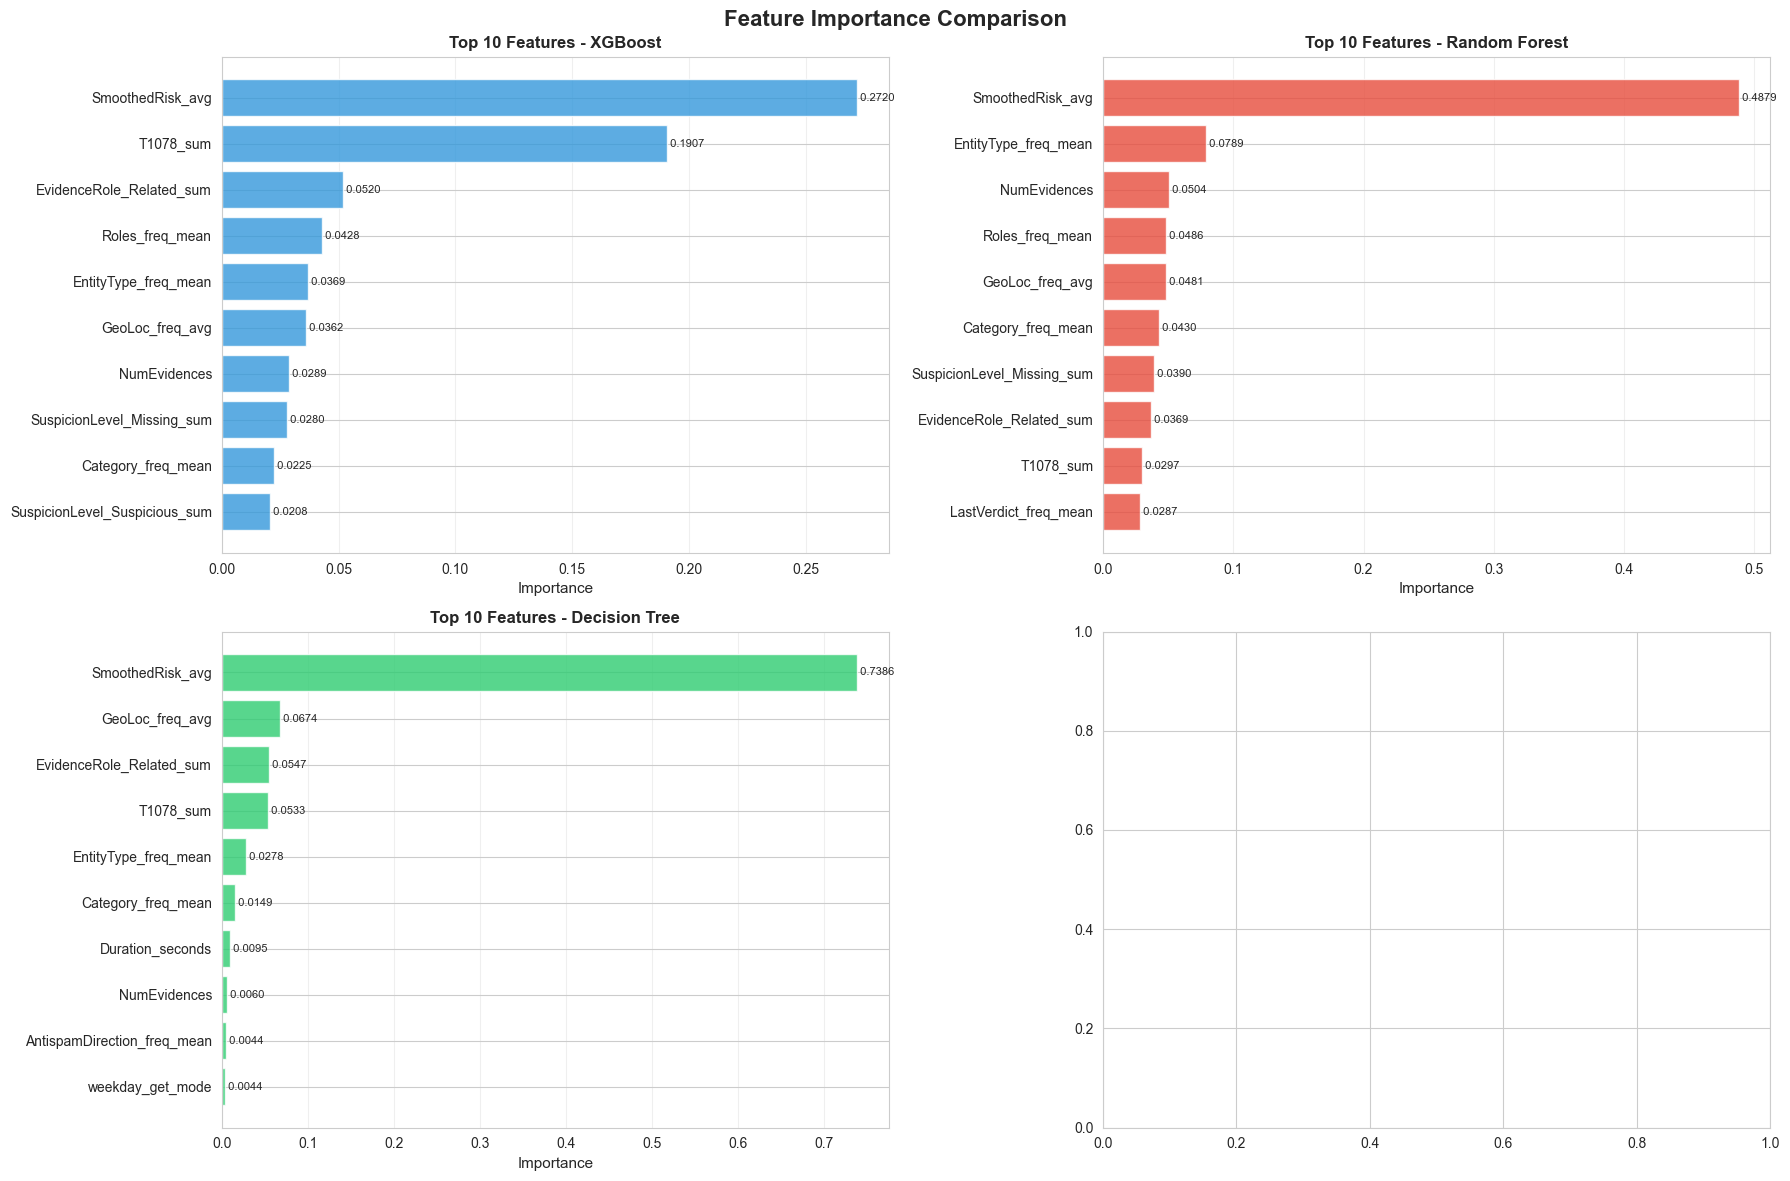

✅ Salvato: ../models/unified_feature_importance.png


In [ ]:
# Carica feature importance
feature_importances = {}
for model_name, model_path in model_paths.items():
    feat_imp_path = models_dir / model_path / 'feature_importance.csv'
    if feat_imp_path.exists():
        feature_importances[model_name] = pd.read_csv(feat_imp_path)
        print(f"✅ {model_name}: {len(feature_importances[model_name])} features")

# Visualizza top 10
n_models = len(feature_importances)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for i, (model_name, feat_df) in enumerate(feature_importances.items()):
    ax = axes[i]
    top = feat_df.head(10).sort_values('Importance', ascending=True)
    
    ax.barh(top['Feature'], top['Importance'], 
            color=colors_palette[i], alpha=0.8)
    ax.set_xlabel('Importance', fontsize=11)
    ax.set_title(f'Top 10 Features - {model_name}', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    for j, (feat, imp) in enumerate(zip(top['Feature'], top['Importance'])):
        ax.text(imp, j, f' {imp:.4f}', va='center', fontsize=8)

plt.suptitle('Feature Importance Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/unified_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Salvato: ../models/unified_feature_importance.png")

### 6.1 Features Comuni

TOP 15 FEATURES COMUNI
                      Feature  Count  Percentage
             SmoothedRisk_avg      3       100.0
                    T1078_sum      3       100.0
     EvidenceRole_Related_sum      3       100.0
         EntityType_freq_mean      3       100.0
              GeoLoc_freq_avg      3       100.0
                 NumEvidences      3       100.0
           Category_freq_mean      3       100.0
              Roles_freq_mean      2        66.7
   SuspicionLevel_Missing_sum      2        66.7
SuspicionLevel_Suspicious_sum      1        33.3
        LastVerdict_freq_mean      1        33.3
             Duration_seconds      1        33.3
  AntispamDirection_freq_mean      1        33.3
             weekday_get_mode      1        33.3


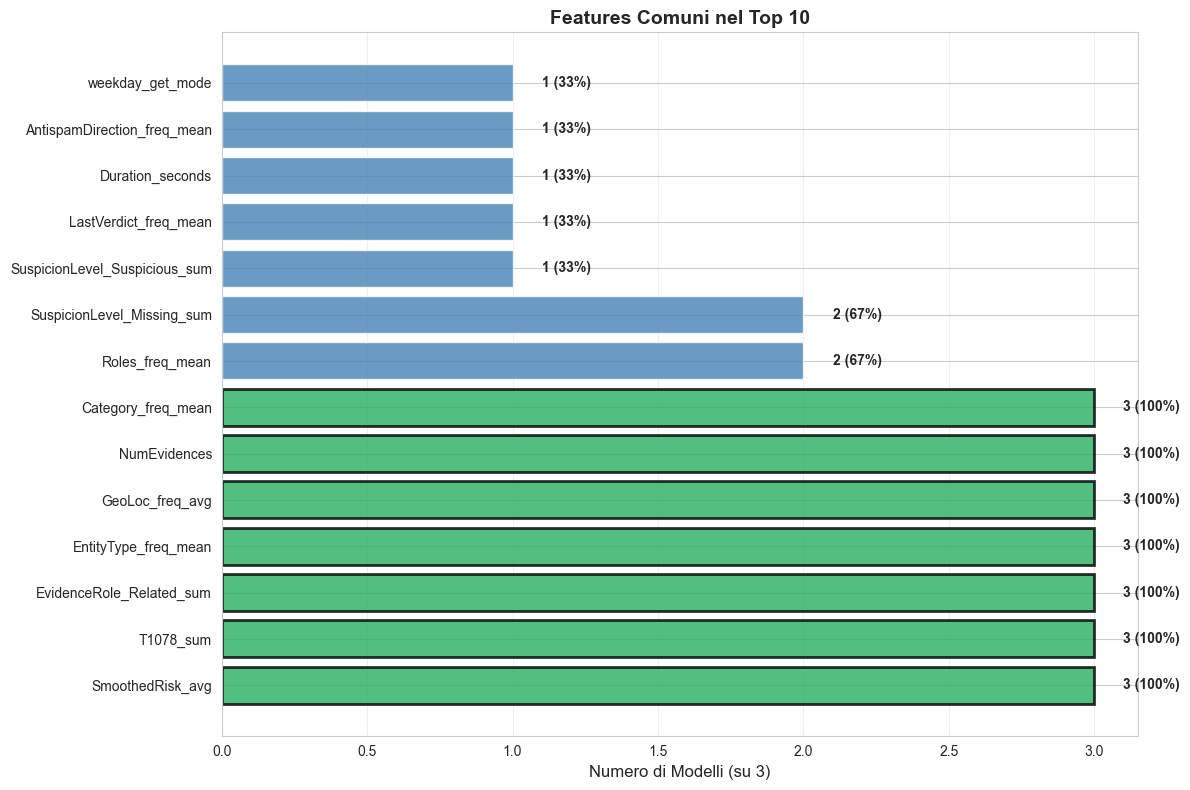


✅ Salvato: ../models/unified_common_features.png


In [ ]:
# Features comuni nel top 10
top_features_count = Counter()
for model_name, feat_df in feature_importances.items():
    top_features_count.update(feat_df.head(10)['Feature'].tolist())

common_features = pd.DataFrame(
    top_features_count.most_common(15), 
    columns=['Feature', 'Count']
)
common_features['Percentage'] = (common_features['Count'] / len(feature_importances) * 100).round(1)

print("=" * 70)
print("TOP 15 FEATURES COMUNI")
print("=" * 70)
print(common_features.to_string(index=False))
print("=" * 70)

# Visualizza
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(common_features['Feature'], common_features['Count'], 
               color='steelblue', alpha=0.8)

for i, bar in enumerate(bars):
    if common_features.iloc[i]['Count'] == len(feature_importances):
        bar.set_color('#27ae60')
        bar.set_edgecolor('black')
        bar.set_linewidth(2)

ax.set_xlabel(f'Numero di Modelli (su {len(feature_importances)})', fontsize=12)
ax.set_title('Features Comuni nel Top 10', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, (feat, count, pct) in enumerate(zip(common_features['Feature'], 
                                            common_features['Count'], 
                                            common_features['Percentage'])):
    ax.text(count + 0.1, i, f'{count} ({pct:.0f}%)', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../models/unified_common_features.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Salvato: ../models/unified_common_features.png")

## 7. Prediction Correlation

In [ ]:
# Il codice di caricamento predizioni è stato spostato alla sezione 4.1 
# per rendere disponibile la variabile 'predictions' necessaria alle Confusion Matrices.
#
# La sezione seguente usa le predizioni già caricate.

Caricamento test set...
Test set: 134,671 samples, 43 features

✅ XGBoost


[Parallel(n_jobs=14)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  22 tasks      | elapsed:    0.0s
[Parallel(n_jobs=14)]: Done 100 out of 100 | elapsed:    0.1s finished


✅ Random Forest
✅ Decision Tree


In [ ]:
# Correlation matrix
predictions_df = pd.DataFrame(predictions)
predictions_df['True_Label'] = y_test.values

# Correlazione solo tra predizioni dei modelli
correlation_matrix = predictions_df.drop('True_Label', axis=1).corr(method='pearson')

print("=" * 80)
print("CORRELATION MATRIX - PREDIZIONI TRA MODELLI")
print("=" * 80)
print(correlation_matrix.round(4))
print("=" * 80)

# Visualizza
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
sns.heatmap(correlation_matrix, annot=True, fmt='.4f', cmap='RdYlGn',
            center=0.5, vmin=0, vmax=1, square=True, linewidths=1,
            cbar_kws={"shrink": 0.8}, ax=ax, mask=mask)

ax.set_title('Correlation Matrix - Model Predictions', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../models/unified_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Salvato: ../models/unified_correlation_matrix.png")

# Opzionale: mostra correlazione con True_Label separatamente
print("\n" + "=" * 80)
print("CORRELAZIONE CON TRUE LABEL (Accuracy Indicator)")
print("=" * 80)
true_label_corr = predictions_df.corr(method='pearson')['True_Label'].drop('True_Label').sort_values(ascending=False)
for model, corr in true_label_corr.items():
    print(f"{model:20s}: {corr:.4f}")
print("=" * 80)

## 8. Agreement Analysis

In [ ]:
model_cols = [col for col in predictions_df.columns if col != 'True_Label']

# Pairwise agreement
print("=" * 80)
print("PAIRWISE AGREEMENT RATE")
print("=" * 80)
for i, m1 in enumerate(model_cols):
    for m2 in model_cols[i+1:]:
        agreement = (predictions_df[m1] == predictions_df[m2]).mean()
        print(f"{m1:20s} vs {m2:20s}: {agreement:.2%}")

# Consensus analysis
all_agree = predictions_df[model_cols].nunique(axis=1) == 1
all_correct = all_agree & (predictions_df[model_cols[0]] == predictions_df['True_Label'])
all_wrong = all_agree & (predictions_df[model_cols[0]] != predictions_df['True_Label'])

print("\n" + "=" * 80)
print("CONSENSUS ANALYSIS")
print("=" * 80)
print(f"Tutti concordano:     {all_agree.sum():7,} ({all_agree.mean():.2%})")
print(f"  Tutti corretti:     {all_correct.sum():7,} ({all_correct.mean():.2%})")
print(f"  Tutti sbagliati:    {all_wrong.sum():7,} ({all_wrong.mean():.2%})")
print(f"Discordano:           {(~all_agree).sum():7,} ({(~all_agree).mean():.2%})")
print("=" * 80)

# Accuracy by agreement level
agree_accuracy = (predictions_df[all_agree][model_cols[0]] == predictions_df[all_agree]['True_Label']).mean()
disagree_accuracies = []
for model in model_cols:
    acc = (predictions_df[~all_agree][model] == predictions_df[~all_agree]['True_Label']).mean()
    disagree_accuracies.append(acc)

print(f"\n💡 Quando concordano → Accuracy: {agree_accuracy:.2%}")
print(f"   Quando discordano → Accuracy media: {np.mean(disagree_accuracies):.2%}")

In [ ]:
# Visualizza agreement analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Agreement distribution
ax = axes[0]
agreement_counts = predictions_df[model_cols].nunique(axis=1)
agreement_dist = agreement_counts.value_counts().sort_index()

bars = ax.bar(agreement_dist.index, agreement_dist.values, 
              color='steelblue', alpha=0.8, edgecolor='black')
ax.set_xlabel('Number of Unique Predictions', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Model Agreement', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for idx, val in agreement_dist.items():
    pct = val / len(predictions_df) * 100
    ax.text(idx, val + 500, f'{val:,}\n({pct:.1f}%)', 
            ha='center', fontsize=10, fontweight='bold')

# Accuracy by agreement
ax = axes[1]
accuracy_by_agreement = []
agreement_levels = sorted(agreement_counts.unique())

for level in agreement_levels:
    mask = agreement_counts == level
    accs = []
    for model in model_cols:
        acc = (predictions_df[mask][model] == predictions_df[mask]['True_Label']).mean()
        accs.append(acc)
    accuracy_by_agreement.append(np.mean(accs))

colors_grad = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(agreement_levels)))
bars = ax.bar(agreement_levels, accuracy_by_agreement, 
              color=colors_grad, alpha=0.8, edgecolor='black')

ax.set_xlabel('Number of Unique Predictions', fontsize=12)
ax.set_ylabel('Average Accuracy', fontsize=12)
ax.set_title('Accuracy by Agreement Level', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0.5, 1.0)

for level, acc in zip(agreement_levels, accuracy_by_agreement):
    ax.text(level, acc + 0.01, f'{acc:.2%}', 
            ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../models/unified_agreement_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Salvato: ../models/unified_agreement_analysis.png")

## 9. Summary

In [ ]:
print("=" * 100)
print("SUMMARY REPORT")
print("=" * 100)

print("\n📊 METRICHE:")
print(comparison_df.sort_values('ROC AUC', ascending=False).to_string(index=False))

print("\n🏆 VINCITORI:")
for metric in ['Accuracy', 'F1-Score', 'ROC AUC']:
    valid = comparison_df[comparison_df[metric].notna()]
    if len(valid) > 0:
        best = valid.loc[valid[metric].idxmax()]
        print(f"  {metric:12s}: {best['Model']:20s} ({best[metric]:.4f})")

print("\n🔑 TOP 5 FEATURES COMUNI:")
for i, row in common_features.head(5).iterrows():
    print(f"  {i+1}. {row['Feature']:30s} ({row['Count']}/{len(feature_importances)} modelli)")

print("\n💡 CONSENSUS:")
print(f"  Modelli concordano:  {all_agree.mean():.1%} dei casi")
print(f"  Accuracy consensus:  {agree_accuracy:.2%}")
print(f"  Accuracy disagreement: {np.mean(disagree_accuracies):.2%}")

print("\n🎯 RACCOMANDAZIONE:")
best_overall = comparison_df.sort_values('ROC AUC', ascending=False).iloc[0]
print(f"  Miglior modello: {best_overall['Model']} (ROC AUC: {best_overall['ROC AUC']:.4f})")

print("\n📁 GRAFICI SALVATI:")
plots = [
    'unified_metrics_comparison.png',
    'unified_confusion_matrices.png',
    'unified_feature_importance.png',
    'unified_common_features.png',
    'unified_correlation_matrix.png',
    'unified_agreement_analysis.png'
]
for plot in plots:
    print(f"  - ../models/{plot}")

print("=" * 100)